In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## EDA, Cleaning and Feature Engineering

In [2]:
df = pd.read_csv("diabetes.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
df.info()
print("İsnull Values: ", "\n", df.isnull().sum())
display(df.head(5))
display(df.describe())

Shape:  (768, 9)
Columns:  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
İsnull Values:  
 Pregnancies        

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    zero_percentage = (zero_count * 100) / 768
    print(f"{col}: Zero Count: {zero_count}, Zero Percentage: {zero_percentage:.2f}")

Glucose: Zero Count: 5, Zero Percentage: 0.65
BloodPressure: Zero Count: 35, Zero Percentage: 4.56
SkinThickness: Zero Count: 227, Zero Percentage: 29.56
Insulin: Zero Count: 374, Zero Percentage: 48.70
BMI: Zero Count: 11, Zero Percentage: 1.43


In [4]:
def plot_numerics(data):
    columns = df.columns
    numeric_cols = [i for i in columns if data[i].dtype != "O"]
    fig, ax = plt.subplots(3,3,figsize=(20, 10))
    ax = ax.flatten()
    for i, col in enumerate(columns):
        sns.histplot(
            data = data,
            x = col,
            ax = ax[i],
            kde=True
        )
        ax[i].set_title(f"{col} Histplot")

    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(3,3,figsize=(20, 10))
    ax2 = ax2.flatten()
    for i, col in enumerate(columns):
        sns.boxplot(
            data = data,
            y = col,
            ax = ax2[i]
        )
        ax2[i].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

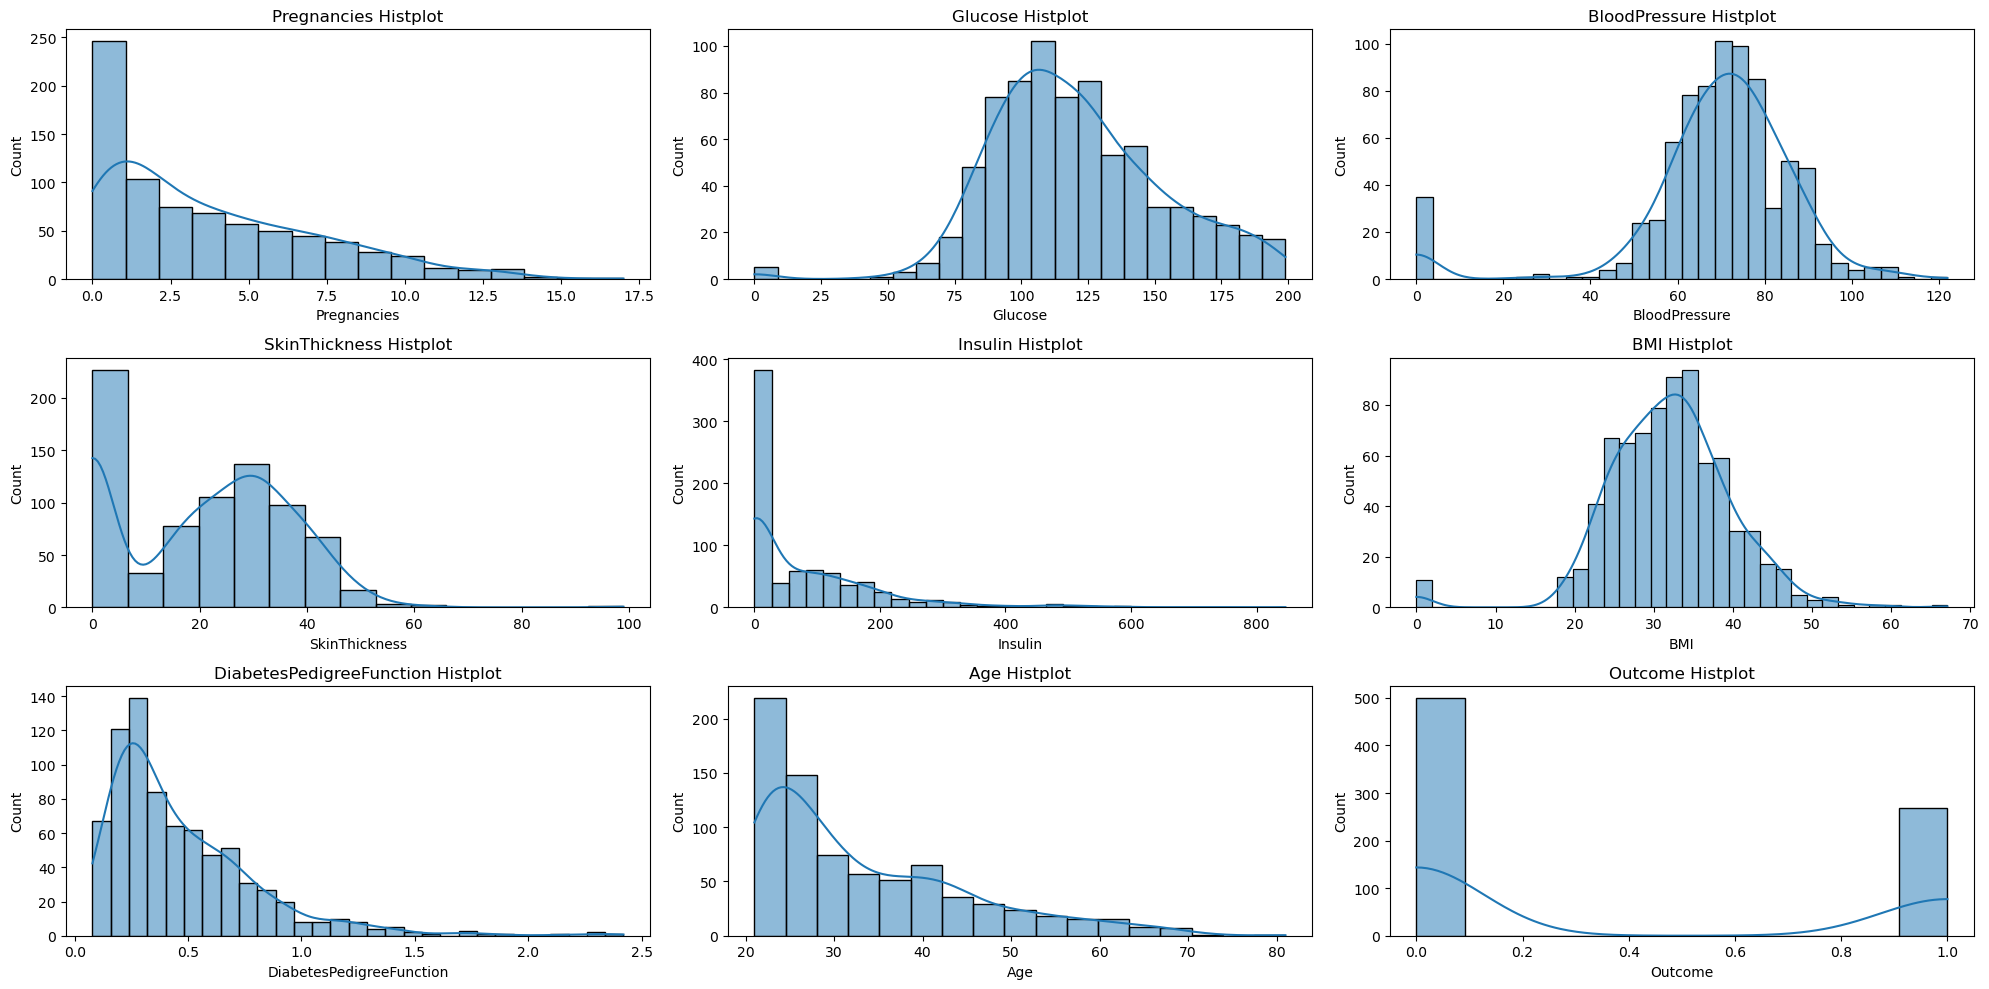

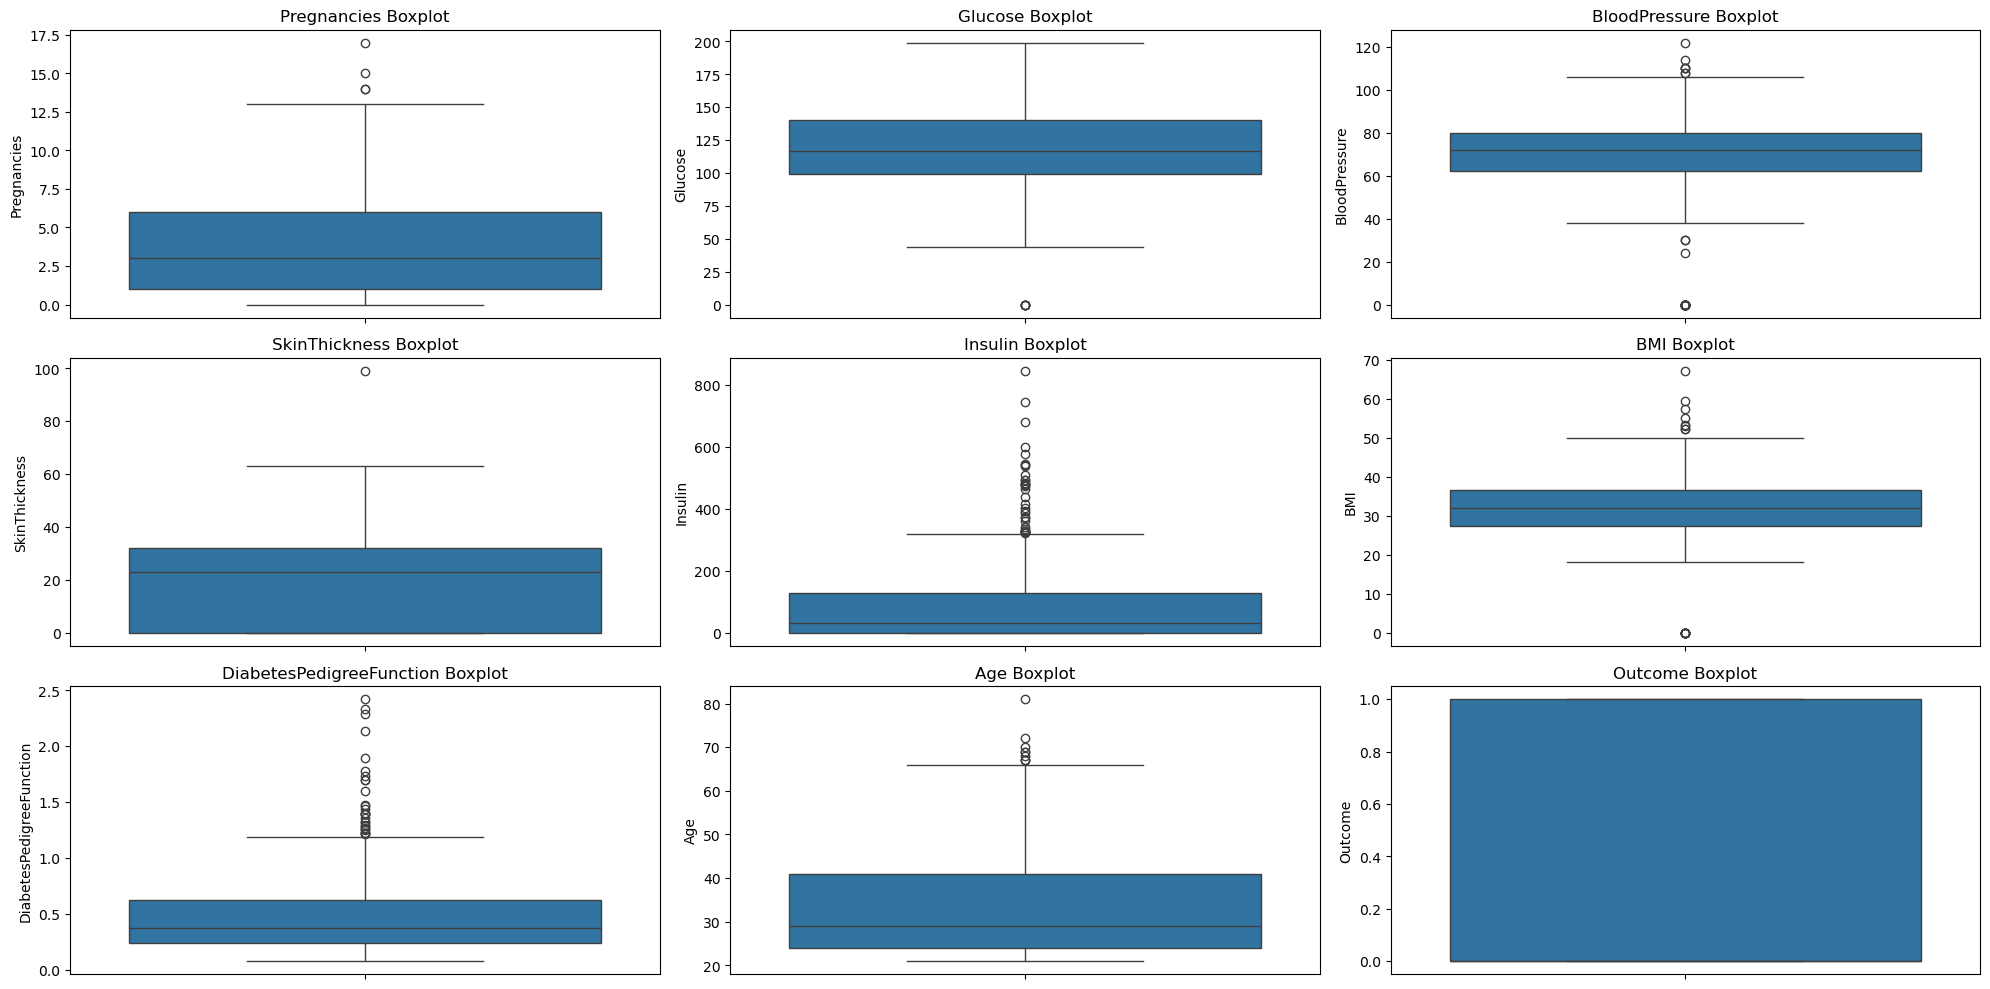

In [5]:
plot_numerics(df)

In [6]:
df[columns_to_check] = df[columns_to_check].replace(0, np.nan)
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [8]:
median_columns = ["Insulin", "Glucose", "BloodPressure", "SkinThickness", "BMI"]
for l in median_columns:
    median = X_train[l].median()
    X_train[l] = X_train[l].fillna(median)
    X_test[l] = X_test[l].fillna(median)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

def calculate_metrics(y_true, predicted):
    accuracy = accuracy_score(y_true, predicted)
    report = classification_report(y_true, predicted)
    matrix = confusion_matrix(y_true, predicted)
    return (accuracy, report, matrix)

def compare(models, X_tr, X_ts, y_tr, y_ts):
    model_values = list(models.values())
    model_keys = list(models.keys())

    for name, model in zip(model_keys, model_values):
        model.fit(X_tr, y_tr)
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_ts)

        accuracy_tr, report_tr, confusion_matrix_tr = calculate_metrics(y_tr, y_pred_train)
        accuracy_ts, report_ts, confusion_matrix_ts = calculate_metrics(y_ts, y_pred_test)

        print(name)
        
        print("Evaluation for Training:")
        print("Accuracy", accuracy_tr)
        print("Classification Report:")
        print(report_tr)
        print("Confusion Matrix:")
        print(confusion_matrix_tr)
        
        print("--------------------------")

        print("Evaluation for Test:")
        print("Accuracy", accuracy_ts)
        print("Classification Report:")
        print(report_ts)
        print("Confusion Matrix:")
        print(confusion_matrix_ts)
        print("--------------------------")

models = {
    "Logistic Regression": LogisticRegression(),
    "SVC": SVC(),
    "Gaussian": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [11]:
compare(models, X_train_scaled, X_test_scaled, y_train, y_test)

Logistic Regression
Evaluation for Training:
Accuracy 0.7829861111111112
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       371
           1       0.75      0.59      0.66       205

    accuracy                           0.78       576
   macro avg       0.77      0.74      0.75       576
weighted avg       0.78      0.78      0.78       576

Confusion Matrix:
[[331  40]
 [ 85 120]]
--------------------------
Evaluation for Test:
Accuracy 0.7604166666666666
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       129
           1       0.65      0.57      0.61        63

    accuracy                           0.76       192
   macro avg       0.73      0.71      0.72       192
weighted avg       0.75      0.76      0.76       192

Confusion Matrix:
[[110  19]
 [ 27  36]]
--------------------------
SVC
Evaluation for Training:
Accuracy 0.83

In [13]:
from sklearn.model_selection import GridSearchCV

def tuning(X_train, X_test, y_train, y_test):
    
    svc_params = {
        "C": [100, 10, 1, 0.1, 0.01],
        "kernel": ["linear", "rbf"],
        "gamma": ["auto", "scale"]
    }
    
    dtc_params = {
        "max_depth": [1,2,3,5,7,10,12,None],
        "max_features": ["sqrt", "log2", 5, 6, 7, 8],
        "min_samples_split": [2, 3, 5, 10, 12]
    }
    
    rfc_params = {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [1,2,3,5,7,10,12,None],
        "max_features": ["sqrt", "log2", 5, 6, 7, 8],
        "min_samples_split": [2, 3, 5, 10, 12]
    }

    abst_params = {
        "n_estimators": [20, 50, 70, 100, 200],
        "learning_rate": [0.01, 0.1, 1, 10 ,100]
    }
    
    gridcv_models = [
        ("SVC", SVC(), svc_params),
        ("Decision Tree Classifier", DecisionTreeClassifier(), dtc_params),
        ("Random Forest Classifier", RandomForestClassifier(), rfc_params),
        ("AdaBoost Classifier", AdaBoostClassifier(), abst_params)
    ]

    for name, model, param in gridcv_models:
        grid = GridSearchCV(estimator=model, param_grid=param, cv=5, n_jobs=-1, scoring="accuracy")
        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)
        print(f"Best Parameters for {name}: ", "\n", grid.best_params_)
        print("Accuracy: ", accuracy_score(y_test, y_pred))
        print("Classificaiton Report: ", "\n", classification_report(y_test, y_pred))
        print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred))
        print("-------------------------")

tuning(X_train_scaled, X_test_scaled, y_train, y_test)

Best Parameters for SVC:  
 {'C': 1, 'gamma': 'auto', 'kernel': 'linear'}
Accuracy:  0.765625
Classificaiton Report:  
               precision    recall  f1-score   support

           0       0.80      0.88      0.83       129
           1       0.68      0.54      0.60        63

    accuracy                           0.77       192
   macro avg       0.74      0.71      0.72       192
weighted avg       0.76      0.77      0.76       192

Confusion Matrix:  
 [[113  16]
 [ 29  34]]
-------------------------
Best Parameters for Decision Tree Classifier:  
 {'max_depth': 3, 'max_features': 6, 'min_samples_split': 2}
Accuracy:  0.6822916666666666
Classificaiton Report:  
               precision    recall  f1-score   support

           0       0.77      0.75      0.76       129
           1       0.52      0.54      0.53        63

    accuracy                           0.68       192
   macro avg       0.64      0.65      0.64       192
weighted avg       0.69      0.68      0.68   

In [23]:
X1 = df.drop(["Insulin", "SkinThickness", "Outcome"], axis=1)
y1 = df["Outcome"]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=15)

In [24]:
median_columns = ["Glucose", "BloodPressure", "BMI"]
for l in median_columns:
    median = X_train1[l].median()
    X_train1[l] = X_train1[l].fillna(median)
    X_test1[l] = X_test1[l].fillna(median)

In [25]:
scaler1 = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVC": SVC(),
    "Gaussian": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "AdaBoost Classifier": AdaBoostClassifier()
}
compare(models, X_train1_scaled, X_test1_scaled, y_train1, y_test1)

Logistic Regression
Evaluation for Training:
Accuracy 0.7752442996742671
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       392
           1       0.73      0.60      0.66       222

    accuracy                           0.78       614
   macro avg       0.76      0.74      0.75       614
weighted avg       0.77      0.78      0.77       614

Confusion Matrix:
[[342  50]
 [ 88 134]]
--------------------------
Evaluation for Test:
Accuracy 0.7532467532467533
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       108
           1       0.59      0.57      0.58        46

    accuracy                           0.75       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:
[[90 18]
 [20 26]]
--------------------------
SVC
Evaluation for Training:
Accuracy 0.819218

In [27]:
tuning(X_train1_scaled, X_test1_scaled, y_train1, y_test1)

Best Parameters for SVC:  
 {'C': 0.01, 'gamma': 'auto', 'kernel': 'linear'}
Accuracy:  0.7597402597402597
Classificaiton Report:  
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       108
           1       0.60      0.57      0.58        46

    accuracy                           0.76       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.76      0.76      0.76       154

Confusion Matrix:  
 [[91 17]
 [20 26]]
-------------------------
Best Parameters for Decision Tree Classifier:  
 {'max_depth': 5, 'max_features': 5, 'min_samples_split': 2}
Accuracy:  0.6688311688311688
Classificaiton Report:  
               precision    recall  f1-score   support

           0       0.76      0.77      0.76       108
           1       0.44      0.43      0.44        46

    accuracy                           0.67       154
   macro avg       0.60      0.60      0.60       154
weighted avg       0.67      0.67    